# 03 · Tutelas — Indicadores y Hallazgos
**Objetivo:** Responder cada pregunta del reto con un número concreto o un patrón visible.

**Prerequisito:** haber corrido `02_tutelas_quality.ipynb` (genera `data/processed/tutelas_clean.csv`).

Bloques:
- **A** — Oportunidad y cumplimiento de términos
- **B** — Concentración de riesgos
- **C** — Favorabilidad de fallos
- **D** — Casos críticos y priorización
- **E** — Cuellos de botella por etapa

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 70)

CLEAN_PATH = '../data/processed/tutelas_clean.csv'
REFERENCE_DATE = pd.Timestamp('2026-05-11')

# Término legal: 48h hábiles para contestar la admisión de tutela
HORAS_TERMINO_ADMISION = 48

In [2]:
df = pd.read_csv(CLEAN_PATH, encoding='utf-8')

date_cols = [
    'Fecha y hora notificación tutela',
    'Fecha Vencimiento Admision',
    'Fecha y hora de Contestación',
    'Fecha y hora notificación 1ra Instancia',
    'Fecha vencimiento fallo 1ra Instancia',
    'Fecha y hora Notificación 2da Instancia',
    'Fecha vencimiento fallo 2da Instancia',
    'Fecha finalización concepto',
    'Fecha Limite Concepto Admisión',
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Trabajamos solo con registros de calidad OK para los indicadores
df_ok = df[df['calidad_dato'] == 'OK'].copy()
print(f'Total registros: {len(df):,} | Registros OK para análisis: {len(df_ok):,}')

Total registros: 12,751 | Registros OK para análisis: 12,726


---
## Bloque A — Oportunidad y cumplimiento de términos
> Pregunta: ¿Qué porcentaje de tutelas se contestaron a tiempo? ¿Qué variables impactan la oportunidad?

In [4]:
# Oportunidad de contestación vs. Fecha Vencimiento Admision (plazo legal real)
df_ok['tiene_contestacion'] = df_ok['Fecha y hora de Contestación'].notna()
df_ok['contesto_a_tiempo'] = (
    df_ok['Fecha y hora de Contestación'] <= df_ok['Fecha Vencimiento Admision']
)
# Horas reales (para análisis de demora)
df_ok['horas_hasta_contestacion'] = (
    df_ok['Fecha y hora de Contestación'] - df_ok['Fecha y hora notificación tutela']
).dt.total_seconds() / 3600

# KPI global
total_con_contestacion = df_ok['tiene_contestacion'].sum()
tasa_oportuno = df_ok.loc[df_ok['tiene_contestacion'], 'contesto_a_tiempo'].mean() * 100
sin_contestacion = (~df_ok['tiene_contestacion']).sum()

print('═══ KPI: Oportunidad de Contestación ═══')
print(f'  Con contestación registrada: {total_con_contestacion:,} ({total_con_contestacion/len(df_ok)*100:.1f}%)')
print(f'  Sin contestación registrada: {sin_contestacion:,} ({sin_contestacion/len(df_ok)*100:.1f}%)')
print(f'  Tasa de contestación oportuna (vs. Fecha Vencimiento Admisión): {tasa_oportuno:.1f}%')
print(f'  Promedio horas hasta contestar: {df_ok["horas_hasta_contestacion"].mean():.1f}h')
print(f'  Mediana horas hasta contestar: {df_ok["horas_hasta_contestacion"].median():.1f}h')


═══ KPI: Oportunidad de Contestación ═══
  Con contestación registrada: 11,868 (93.3%)
  Sin contestación registrada: 858 (6.7%)
  Tasa de contestación oportuna (vs. Fecha Vencimiento Admisión): 90.7%
  Promedio horas hasta contestar: 68.2h
  Mediana horas hasta contestar: 52.5h


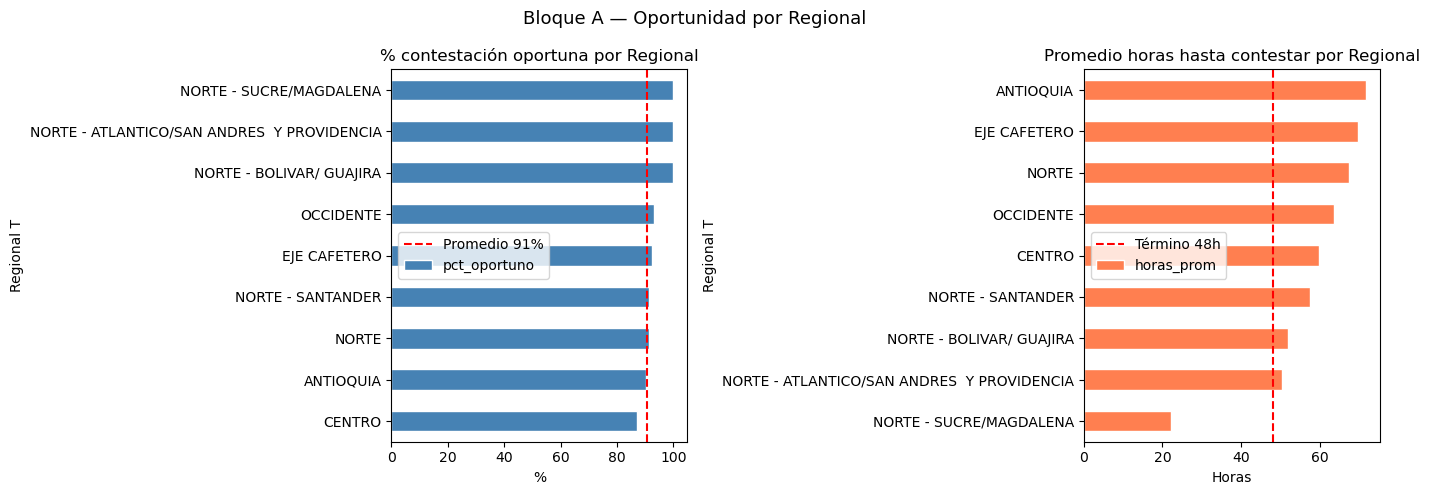

                                             total  a_tiempo  horas_prom  pct_oportuno
Regional T                                                                            
CENTRO                                        1593      1386   59.899705     87.005650
ANTIOQUIA                                     5619      5079   71.737093     90.389749
NORTE                                         1812      1657   67.345552     91.445916
NORTE - SANTANDER                               59        54   57.499642     91.525424
EJE CAFETERO                                  1285      1186   69.638773     92.295720
OCCIDENTE                                     1497      1396   63.692568     93.253173
NORTE - BOLIVAR/ GUAJIRA                         1         1   51.976944    100.000000
NORTE - ATLANTICO/SAN ANDRES  Y PROVIDENCIA      1         1   50.323333    100.000000
NORTE - SUCRE/MAGDALENA                          1         1   22.253056    100.000000


In [5]:
# Oportunidad por Regional
oport_regional = (
    df_ok[df_ok['tiene_contestacion']]
    .groupby('Regional T')
    .agg(
        total=('contesto_a_tiempo', 'count'),
        a_tiempo=('contesto_a_tiempo', 'sum'),
        horas_prom=('horas_hasta_contestacion', 'mean')
    )
    .assign(pct_oportuno=lambda x: x['a_tiempo'] / x['total'] * 100)
    .sort_values('pct_oportuno')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

oport_regional['pct_oportuno'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(tasa_oportuno, color='red', linestyle='--', linewidth=1.5, label=f'Promedio {tasa_oportuno:.0f}%')
axes[0].set_title('% contestación oportuna por Regional')
axes[0].set_xlabel('%')
axes[0].legend()

oport_regional['horas_prom'].sort_values().plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].axvline(HORAS_TERMINO_ADMISION, color='red', linestyle='--', linewidth=1.5, label=f'Término {HORAS_TERMINO_ADMISION}h')
axes[1].set_title('Promedio horas hasta contestar por Regional')
axes[1].set_xlabel('Horas')
axes[1].legend()

plt.suptitle('Bloque A — Oportunidad por Regional', fontsize=13)
plt.tight_layout()
plt.show()
print(oport_regional.to_string())

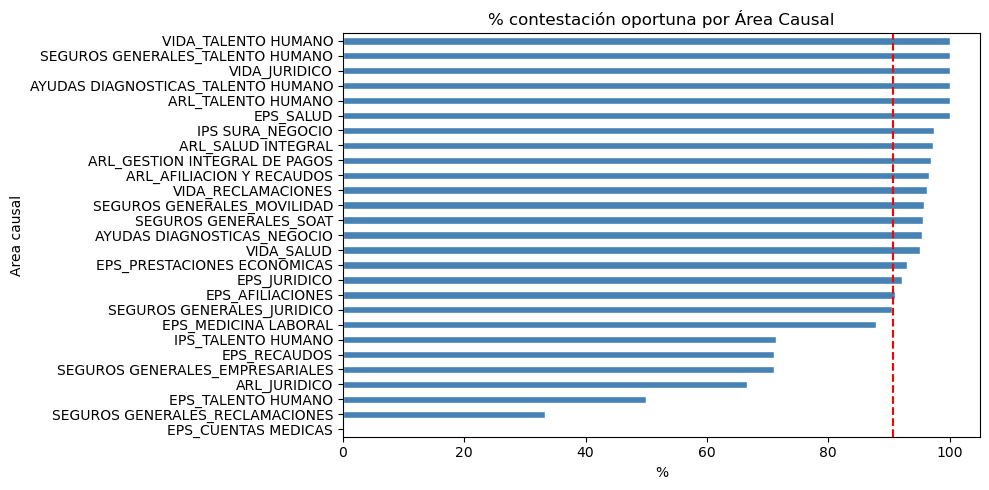

                                    total  a_tiempo  horas_prom  pct_oportuno
Area causal                                                                  
EPS_CUENTAS MEDICAS                     1         0   92.963333      0.000000
SEGUROS GENERALES_RECLAMACIONES         3         1   58.955648     33.333333
EPS_TALENTO HUMANO                      2         1   25.592222     50.000000
ARL_JURIDICO                            3         2   67.500648     66.666667
SEGUROS GENERALES_EMPRESARIALES        38        27   67.989115     71.052632
EPS_RECAUDOS                           38        27   87.825519     71.052632
IPS_TALENTO HUMANO                      7         5   77.610278     71.428571
EPS_MEDICINA LABORAL                  769       676   68.171076     87.906372
SEGUROS GENERALES_JURIDICO             21        19   48.093929     90.476190
EPS_AFILIACIONES                      880       800   66.144126     90.909091
EPS_JURIDICO                          152       140   57.973765 

In [6]:
# Oportunidad por Área causal
oport_causal = (
    df_ok[df_ok['tiene_contestacion']]
    .groupby('Area causal')
    .agg(
        total=('contesto_a_tiempo', 'count'),
        a_tiempo=('contesto_a_tiempo', 'sum'),
        horas_prom=('horas_hasta_contestacion', 'mean')
    )
    .assign(pct_oportuno=lambda x: x['a_tiempo'] / x['total'] * 100)
    .sort_values('pct_oportuno')
)

fig, ax = plt.subplots(figsize=(10, 5))
oport_causal['pct_oportuno'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.axvline(tasa_oportuno, color='red', linestyle='--', linewidth=1.5)
ax.set_title('% contestación oportuna por Área Causal')
ax.set_xlabel('%')
plt.tight_layout()
plt.show()
print(oport_causal.to_string())

---
## Bloque B — Concentración de riesgos
> Pregunta: ¿Dónde se concentran los principales riesgos? ¿Qué regionales/áreas generan mayor presión operativa?

In [7]:
# Volumen + incumplimiento por Regional x Area causal
riesgo = (
    df_ok[df_ok['tiene_contestacion']]
    .groupby(['Regional T', 'Area causal'])
    .agg(
        total=('contesto_a_tiempo', 'count'),
        incumplidos=('contesto_a_tiempo', lambda x: (~x).sum())
    )
    .assign(pct_incumplimiento=lambda x: x['incumplidos'] / x['total'] * 100)
    .reset_index()
    .sort_values('incumplidos', ascending=False)
)

print('Top 15 combinaciones Regional × Área causal con más incumplimientos:')
print(riesgo.head(15).to_string(index=False))

Top 15 combinaciones Regional × Área causal con más incumplimientos:
  Regional T                     Area causal  total  incumplidos  pct_incumplimiento
   ANTIOQUIA            EPS_MEDICINA LABORAL    420           51           12.142857
   ANTIOQUIA     EPS_PRESTACIONES ECONOMICAS    673           40            5.943536
   ANTIOQUIA                EPS_AFILIACIONES    376           31            8.244681
       NORTE            EPS_MEDICINA LABORAL    112           19           16.964286
       NORTE                EPS_AFILIACIONES    149           17           11.409396
      CENTRO     EPS_PRESTACIONES ECONOMICAS     92           13           14.130435
   OCCIDENTE                EPS_AFILIACIONES    126           12            9.523810
   OCCIDENTE              ARL_SALUD INTEGRAL    262           12            4.580153
      CENTRO              ARL_SALUD INTEGRAL    401           12            2.992519
EJE CAFETERO     EPS_PRESTACIONES ECONOMICAS    100           10           10.000

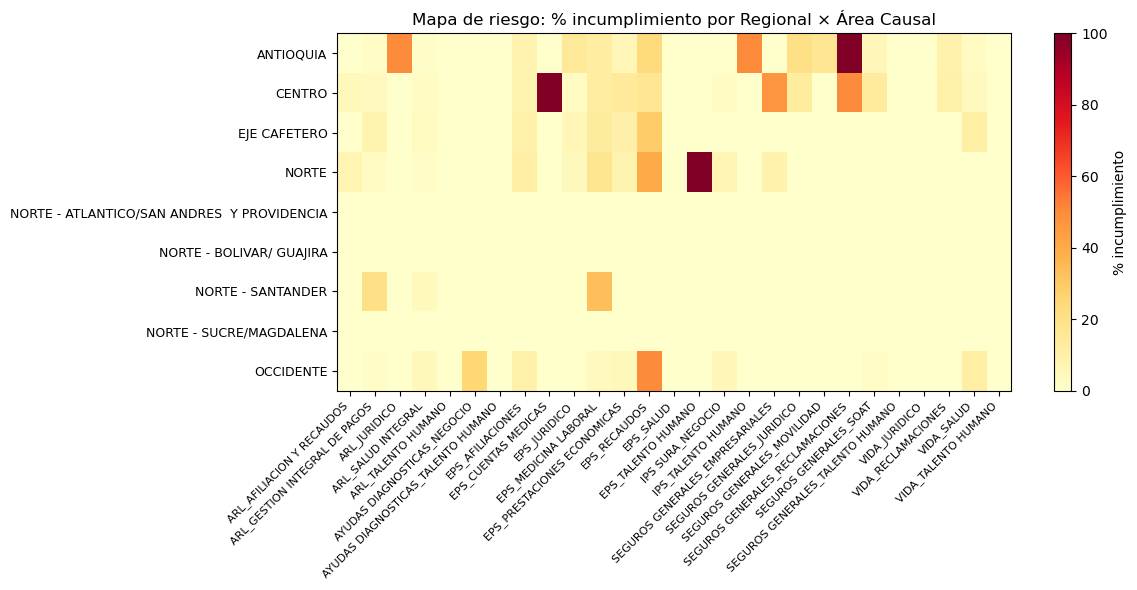

In [8]:
# Mapa de calor: Regional vs Area causal — % incumplimiento
pivot_riesgo = riesgo.pivot_table(
    index='Regional T', columns='Area causal',
    values='pct_incumplimiento', aggfunc='mean'
).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(pivot_riesgo.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(pivot_riesgo.columns)))
ax.set_xticklabels(pivot_riesgo.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(pivot_riesgo.index)))
ax.set_yticklabels(pivot_riesgo.index, fontsize=9)
plt.colorbar(im, ax=ax, label='% incumplimiento')
ax.set_title('Mapa de riesgo: % incumplimiento por Regional × Área Causal', fontsize=12)
plt.tight_layout()
plt.show()

---
## Bloque C — Favorabilidad de fallos
> Pregunta: ¿Cuál es la favorabilidad de las tutelas resueltas?

In [9]:
# Fallo 1ra instancia
fallo1 = df['Clasificación fallo 1ra Instancia'].value_counts(dropna=False)
fallo2 = df['Clasificación fallo 2da Instancia'].value_counts(dropna=False)

print('Distribución fallo 1ra instancia:')
print(fallo1.to_string())
print()
print('Distribución fallo 2da instancia:')
print(fallo2.to_string())

Distribución fallo 1ra instancia:
Clasificación fallo 1ra Instancia
FALLO FAVORABLE       6112
FALLO DESFAVORABLE    5802
NaN                    772
DESISTIMIENTO           64
NULIDAD                  1

Distribución fallo 2da instancia:
Clasificación fallo 2da Instancia
NaN                   11152
FALLO FAVORABLE        1106
FALLO DESFAVORABLE      491
INCIDENTE DESACATO        1
NULIDAD                   1


Tutelas con fallo 1ra instancia registrado: 11,967
  Favorable:    6,105  (51.0%)
  Desfavorable: 5,797  (48.4%)
  Otros:        65  (0.5%)

Tasa de favorabilidad global: 51.0%


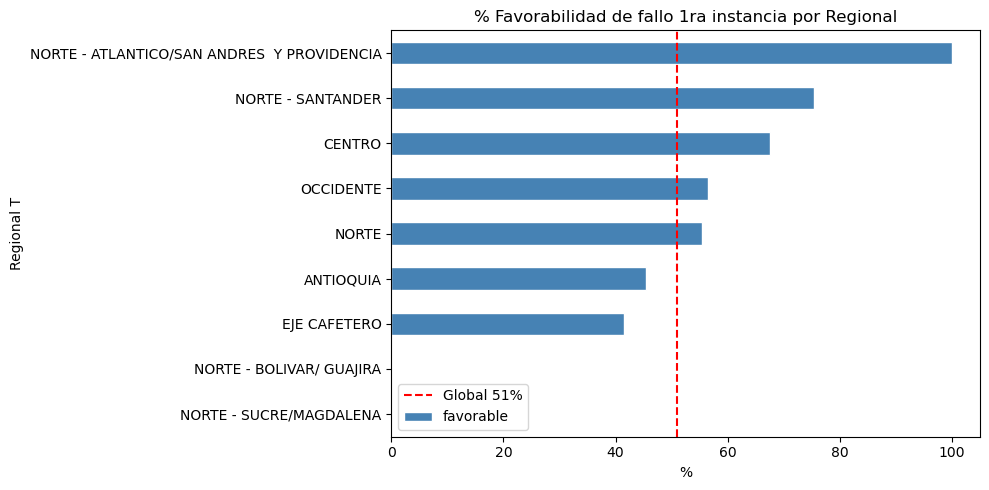

In [11]:
# Favorabilidad global y por Regional
# Valores posibles (normalizados a uppercase en nb02):
# 'FALLO FAVORABLE', 'FALLO DESFAVORABLE', 'DESISTIMIENTO', 'NULIDAD', NaN
df_fallo = df_ok[df_ok['Clasificación fallo 1ra Instancia'].notna()].copy()
df_fallo['favorable'] = df_fallo['Clasificación fallo 1ra Instancia'] == 'FALLO FAVORABLE'
df_fallo['desfavorable'] = df_fallo['Clasificación fallo 1ra Instancia'] == 'FALLO DESFAVORABLE'

n_total = len(df_fallo)
n_fav = df_fallo['favorable'].sum()
n_desfav = df_fallo['desfavorable'].sum()
favorabilidad_global = n_fav / n_total * 100

print(f'Tutelas con fallo 1ra instancia registrado: {n_total:,}')
print(f'  Favorable:    {n_fav:,}  ({n_fav/n_total*100:.1f}%)')
print(f'  Desfavorable: {n_desfav:,}  ({n_desfav/n_total*100:.1f}%)')
print(f'  Otros:        {n_total - n_fav - n_desfav:,}  ({(n_total - n_fav - n_desfav)/n_total*100:.1f}%)')
print(f'\nTasa de favorabilidad global: {favorabilidad_global:.1f}%')

favorabilidad_regional = (
    df_fallo.groupby('Regional T')['favorable']
    .mean()
    .mul(100)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5))
favorabilidad_regional.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.axvline(favorabilidad_global, color='red', linestyle='--', linewidth=1.5, label=f'Global {favorabilidad_global:.0f}%')
ax.set_title('% Favorabilidad de fallo 1ra instancia por Regional')
ax.set_xlabel('%')
ax.legend()
plt.tight_layout()
plt.show()


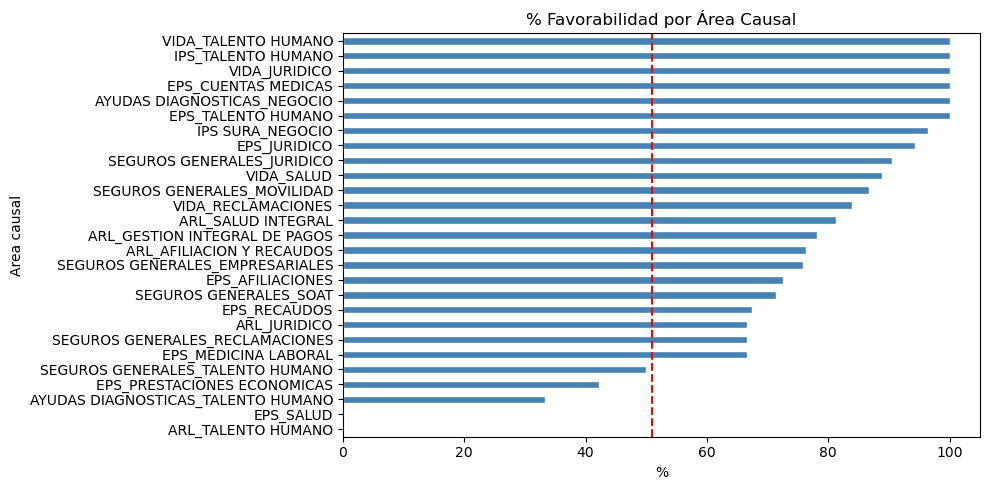

                                        mean  count  pct_favorable
Area causal                                                       
ARL_TALENTO HUMANO                  0.000000      1       0.000000
EPS_SALUD                           0.000000      1       0.000000
AYUDAS DIAGNOSTICAS_TALENTO HUMANO  0.333333      3      33.333333
EPS_PRESTACIONES ECONOMICAS         0.421687   1079      42.168675
SEGUROS GENERALES_TALENTO HUMANO    0.500000      2      50.000000
EPS_MEDICINA LABORAL                0.666235    773      66.623545
SEGUROS GENERALES_RECLAMACIONES     0.666667      3      66.666667
ARL_JURIDICO                        0.666667      3      66.666667
EPS_RECAUDOS                        0.675000     40      67.500000
SEGUROS GENERALES_SOAT              0.714286    196      71.428571
EPS_AFILIACIONES                    0.725490    867      72.549020
SEGUROS GENERALES_EMPRESARIALES     0.757576     33      75.757576
ARL_AFILIACION Y RECAUDOS           0.763636     55      76.36

In [12]:
# Favorabilidad por Área causal
favorabilidad_causal = (
    df_fallo.groupby('Area causal')['favorable']
    .agg(['mean', 'count'])
    .assign(pct_favorable=lambda x: x['mean'] * 100)
    .sort_values('pct_favorable')
)

fig, ax = plt.subplots(figsize=(10, 5))
favorabilidad_causal['pct_favorable'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.axvline(favorabilidad_global, color='red', linestyle='--', linewidth=1.5)
ax.set_title('% Favorabilidad por Área Causal')
ax.set_xlabel('%')
plt.tight_layout()
plt.show()
print(favorabilidad_causal.to_string())

---
## Bloque D — Casos críticos y priorización
> Pregunta: ¿Qué casos deberían priorizarse de inmediato?

In [13]:
# Criterio de criticidad:
# 1. Sin contestación registrada
# 2. Con fallo desfavorable y plazo de cumplimiento próximo o vencido
# 3. Con medida provisional activa

df_activos = df_ok[
    ~df_ok['Estado del ciclo de vida'].str.contains('TERMINADO|TERMINADA|ARCHIVADO', na=False)
].copy()

print(f'Tutelas activas (no terminadas): {len(df_activos):,}')

# Puntaje de criticidad (suma de condiciones)
df_activos['score_criticidad'] = 0

# Sin contestación
df_activos['score_criticidad'] += (~df_activos['tiene_contestacion'].fillna(False)).astype(int) * 3

# Fallo desfavorable
df_activos['score_criticidad'] += df_activos['Clasificación fallo 1ra Instancia'].str.contains('DESFAV', na=False).astype(int) * 2

# Medida provisional
df_activos['score_criticidad'] += df_activos['Medida provisional'].str.contains('SI', na=False).astype(int) * 2

# Días desde notificación sin resolver
df_activos['dias_sin_resolver'] = (
    REFERENCE_DATE - df_activos['Fecha y hora notificación tutela']
).dt.days.clip(lower=0)

# Lista priorizada
criticos = df_activos[df_activos['score_criticidad'] >= 3].sort_values('score_criticidad', ascending=False)

print(f'\nCasos críticos identificados (score ≥ 3): {len(criticos):,}')
cols_vista = ['Nombre del fichero', 'Regional T', 'Area causal', 'Abogado asignado tutela',
              'Medida provisional', 'Clasificación fallo 1ra Instancia', 'dias_sin_resolver', 'score_criticidad']
print(criticos[cols_vista].head(20).to_string(index=False))

Tutelas activas (no terminadas): 11,091

Casos críticos identificados (score ≥ 3): 1,110
                         Nombre del fichero   Regional T      Area causal         Abogado asignado tutela Medida provisional Clasificación fallo 1ra Instancia  dias_sin_resolver  score_criticidad
  EXP-T-26-000001163 - 2026-0016 - 44157395        NORTE              NaN      Edyn Alvaro Berrio Miranda                 SI                FALLO DESFAVORABLE                115                 7
  EXP-T-26-000008354 - 2026-0069 - 51699568       CENTRO              NaN          Valentina Rojas Arango                 SI                FALLO DESFAVORABLE                 72                 7
  EXP-T-26-000006213 - 2026-0126 - 24316633 EJE CAFETERO EPS_AFILIACIONES        Tatiana Rosero Manquillo                 SI                FALLO DESFAVORABLE                 86                 7
  EXP-T-26-000002641 - 2026-0073 - 26027712    ANTIOQUIA              NaN        Ana Judith Balseiro Moya                 SI   

In [14]:
# Exportar lista de casos críticos
import os
os.makedirs('../outputs', exist_ok=True)
criticos[cols_vista].to_csv('../outputs/casos_criticos_tutelas.csv', index=False, encoding='utf-8')
print('Exportado: ../outputs/casos_criticos_tutelas.csv')

Exportado: ../outputs/casos_criticos_tutelas.csv


---
## Bloque E — Cuellos de botella por etapa
> Pregunta: ¿Qué etapas del proceso presentan mayores demoras?

In [15]:
# Tiempos por etapa del proceso
etapas = {
    'Notif → Contestación (admisión)': (
        'Fecha y hora notificación tutela', 'Fecha y hora de Contestación'
    ),
    'Contestación → Fallo 1ra Instancia': (
        'Fecha y hora de Contestación', 'Fecha vencimiento fallo 1ra Instancia'
    ),
    'Fallo 1ra → Notif 2da Instancia': (
        'Fecha vencimiento fallo 1ra Instancia', 'Fecha y hora Notificación 2da Instancia'
    ),
    'Notif 2da → Fallo 2da Instancia': (
        'Fecha y hora Notificación 2da Instancia', 'Fecha vencimiento fallo 2da Instancia'
    ),
}

tiempos = {}
for etapa, (inicio, fin) in etapas.items():
    dias = (df_ok[fin] - df_ok[inicio]).dt.days
    dias = dias[dias.between(0, 365)]  # filtrar outliers extremos
    tiempos[etapa] = dias

resumen_etapas = pd.DataFrame({
    etapa: {
        'n': serie.count(),
        'mediana_dias': serie.median(),
        'promedio_dias': serie.mean(),
        'p90_dias': serie.quantile(0.9),
    }
    for etapa, serie in tiempos.items()
}).T

print('Tiempo por etapa del proceso (días):')
print(resumen_etapas.round(1).to_string())

Tiempo por etapa del proceso (días):
                                          n  mediana_dias  promedio_dias  p90_dias
Notif → Contestación (admisión)     11868.0           2.0            2.4       4.0
Contestación → Fallo 1ra Instancia  11579.0          16.0           16.8      23.0
Fallo 1ra → Notif 2da Instancia      1639.0          31.0           30.7      43.0
Notif 2da → Fallo 2da Instancia      1673.0           7.0            7.6      10.0


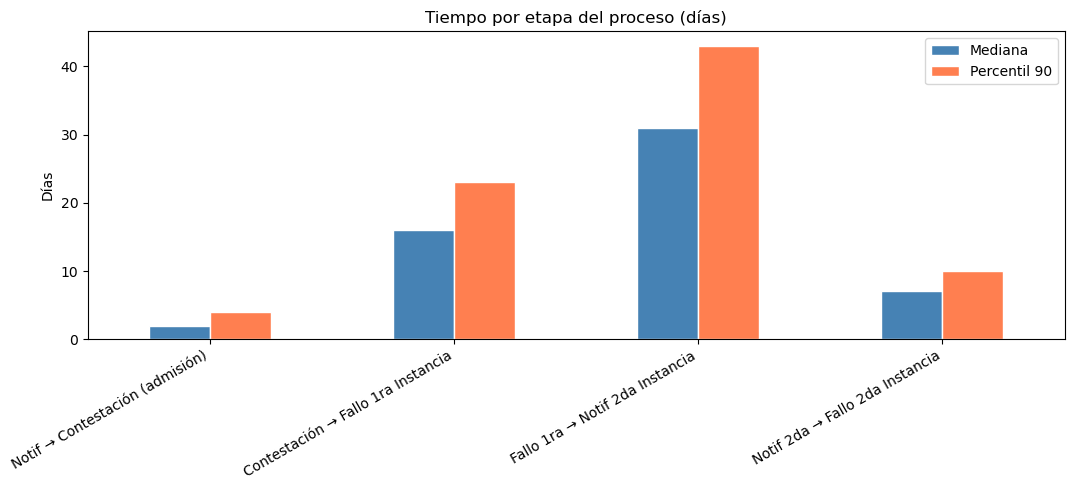

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))
resumen_etapas[['mediana_dias', 'p90_dias']].plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='white')
ax.set_title('Tiempo por etapa del proceso (días)', fontsize=12)
ax.set_ylabel('Días')
ax.set_xticklabels(resumen_etapas.index, rotation=30, ha='right')
ax.legend(['Mediana', 'Percentil 90'])
plt.tight_layout()
plt.show()

---
## Resumen de indicadores finales


In [17]:
# Bloque A
regional_menor_oport = oport_regional['pct_oportuno'].idxmin()
pct_menor_oport = oport_regional['pct_oportuno'].min()

# Bloque B — combinación con más incumplimientos absolutos
top_riesgo = riesgo.iloc[0]

# Bloque C
area_menor_fav = favorabilidad_causal['pct_favorable'].idxmin()
pct_menor_fav = favorabilidad_causal['pct_favorable'].min()

# Bloque D
n_criticos = len(criticos)

# Bloque E
etapa_cuello = resumen_etapas['mediana_dias'].idxmax()
dias_cuello = resumen_etapas.loc[etapa_cuello, 'mediana_dias']

print('═' * 62)
print('  INDICADORES FINALES — TUTELAS 2026')
print('═' * 62)
print(f'  Total tutelas analizadas          {len(df_ok):>8,}')
print(f'  % contestación oportuna           {tasa_oportuno:>7.1f}%')
print(f'  Regional menor oportunidad        {regional_menor_oport}  ({pct_menor_oport:.1f}%)')
print(f'  Combinación riesgo #1             {top_riesgo["Regional T"]} × {top_riesgo["Area causal"]}')
print(f'    └ {top_riesgo["incumplidos"]:.0f} incumplimientos ({top_riesgo["pct_incumplimiento"]:.1f}%)')
print(f'  % favorabilidad fallo 1ra inst.   {favorabilidad_global:>7.1f}%  (51F / 48D)')
print(f'  Área causal menor favorabilidad   {area_menor_fav}  ({pct_menor_fav:.1f}%)')
print(f'  Casos críticos activos            {n_criticos:>8,}')
print(f'  Etapa cuello de botella           {etapa_cuello}')
print(f'    └ mediana {dias_cuello:.0f} días')
print('═' * 62)
print('  → Exportado: outputs/casos_criticos_tutelas.csv')


══════════════════════════════════════════════════════════════
  INDICADORES FINALES — TUTELAS 2026
══════════════════════════════════════════════════════════════
  Total tutelas analizadas            12,726
  % contestación oportuna              90.7%
  Regional menor oportunidad        CENTRO  (87.0%)
  Combinación riesgo #1             ANTIOQUIA × EPS_MEDICINA LABORAL
    └ 51 incumplimientos (12.1%)
  % favorabilidad fallo 1ra inst.      51.0%  (51F / 48D)
  Área causal menor favorabilidad   ARL_TALENTO HUMANO  (0.0%)
  Casos críticos activos               1,110
  Etapa cuello de botella           Fallo 1ra → Notif 2da Instancia
    └ mediana 31 días
══════════════════════════════════════════════════════════════
  → Exportado: outputs/casos_criticos_tutelas.csv
